In [1]:
#Import necessary libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_curve, auc, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, average_precision_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import ParameterGrid
import shap

In [2]:
#Access our Github Repo

!git clone https://github.com/psklam/Team-27-SIADS-699.git

Cloning into 'Team-27-SIADS-699'...
remote: Enumerating objects: 22, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 22 (delta 8), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (22/22), 5.39 MiB | 8.31 MiB/s, done.
Resolving deltas: 100% (8/8), done.


In [3]:
#Load datasets

people_df = pd.read_csv("Team-27-SIADS-699/movie_people.csv")
principals_df = pd.read_csv("Team-27-SIADS-699/movie_principals.csv")
ratings_df = pd.read_csv("Team-27-SIADS-699/movie_ratings.csv")
titles_df = pd.read_csv("Team-27-SIADS-699/movie_titles.csv")
budget_df = pd.read_csv("Team-27-SIADS-699/movies_budget.csv")

In [4]:
#Merge datasets

movies = budget_df.merge(
    titles_df,
    left_on="imdb_id",
    right_on="tconst",
    how="left"
)

movies = movies.merge(
    ratings_df,
    on="tconst",
    how="left"
)

movies_with_principal = movies.merge(
    principals_df[principals_df['ordering'] == 1][['nconst', 'tconst']],
    on='tconst',
    how='left'
)

movies_with_principal_name = movies_with_principal.merge(
    people_df,
    on='nconst',
    how='left'
)

In [5]:
#Filter columns and create basic features

final_filt = movies_with_principal_name[['primaryTitle','primaryName','titleType','genres','runtimeMinutes','budget','revenue','year','averageRating','numVotes']]

final_filt = final_filt.dropna(subset=["primaryTitle","genres","runtimeMinutes","averageRating","numVotes"])

final_filt = final_filt[final_filt["titleType"] == 'movie']

final_filt["profit"] = final_filt["revenue"] - final_filt["budget"]

final_filt["roi"] = final_filt["revenue"] / final_filt["budget"]

final_filt['success'] = (final_filt['revenue'] > 1.25*final_filt['budget']).astype(int)

final_filt['runtimeMinutes'] = pd.to_numeric(final_filt['runtimeMinutes'], errors='coerce')

final_filt = final_filt.copy()

In [6]:
#Filter final dataset to remove very small genres

genre_dummies = final_filt["genres"].str.get_dummies(sep=",")

genre_counts = genre_dummies.sum().sort_values(ascending=False)

major_genres = genre_counts[genre_counts >= 50].index

final_filt = pd.concat([final_filt, genre_dummies[major_genres]], axis=1)

In [7]:
#Display summary metrics for important features

pd.options.display.float_format = '{:,.2f}'.format
final_filt[['roi','averageRating','budget']].describe()

,roi,averageRating,budget
count,"8,279.00","8,279.00","8,279.00"
mean,"1,037.04",6.23,"26,414,884.27"
std,"52,322.89",1.15,"42,394,842.41"
min,0.00,1.00,1.00
25%,0.44,5.60,"2,700,000.00"
50%,1.43,6.40,"10,000,000.00"
75%,3.33,7.00,"30,000,000.00"
max,"3,000,003.50",9.50,"489,900,000.00"


In [8]:
#Create train/val/test splits

train = final_filt[final_filt['year'] <= 2012]
val   = final_filt[(final_filt['year'] > 2012) & (final_filt['year'] <= 2015)]
test  = final_filt[(final_filt['year'] > 2015) & (final_filt['year'] <= 2019)]

In [9]:
#Create function to define budget buckets

def bucket_budget(b):
    if b <= 5_000_000:
        return '0-5M'
    elif b <= 25_000_000:
        return '5-25M'
    elif b <= 100_000_000:
        return '25-100M'
    else:
        return '100M+'

In [10]:
#Create feature for budget buckets

for df in [train, val, test]:
    df['budget_bucket'] = df['budget'].apply(bucket_budget)

/tmp/ipykernel_16376/3310940061.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['budget_bucket'] = df['budget'].apply(bucket_budget)
/tmp/ipykernel_16376/3310940061.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['budget_bucket'] = df['budget'].apply(bucket_budget)
/tmp/ipykernel_16376/3310940061.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:/

In [11]:
# ROI grouped features
genre_med = (
    train.groupby(['budget_bucket', 'genres'])['roi']
    .median()
    .reset_index()
    .rename(columns={'roi': 'med_roi_genre_bucket'})
)

# Rating grouped features
genre_med_ratings = (
    train.groupby(['budget_bucket', 'genres'])['averageRating']
    .median()
    .reset_index()
    .rename(columns={'averageRating': 'med_rating_genre_bucket'})
)

actor_med_ratings = (
    train.groupby(['budget_bucket', 'primaryName'])['averageRating']
    .median()
    .reset_index()
    .rename(columns={'averageRating': 'med_rating_actor_bucket'})
)

# Budget grouped features
genre_med_budget = (
    train.groupby(['budget_bucket', 'genres'])['budget']
    .median()
    .reset_index()
    .rename(columns={'budget': 'med_budget_genre_bucket'})
)

actor_med_budget = (
    train.groupby(['budget_bucket', 'primaryName'])['budget']
    .median()
    .reset_index()
    .rename(columns={'budget': 'med_budget_actor_bucket'})
)

In [12]:
#Merge aggregated features into dataset

merge_configs = [
    (genre_med, ['budget_bucket', 'genres']),
    (genre_med_ratings, ['budget_bucket', 'genres']),
    (actor_med_ratings, ['budget_bucket', 'primaryName']),
    (genre_med_budget, ['budget_bucket', 'genres']),
    (actor_med_budget, ['budget_bucket', 'primaryName']),
]

for df_to_merge, keys in merge_configs:
    train = train.merge(df_to_merge, on=keys, how='left')
    val   = val.merge(df_to_merge, on=keys, how='left')
    test  = test.merge(df_to_merge, on=keys, how='left')

In [13]:
# ROI fallback values
bucket_med_roi = (
    train.groupby('budget_bucket')['roi']
    .median()
)

global_med_roi = train['roi'].median()

# Rating fallback values
bucket_med_rating = (
    train.groupby('budget_bucket')['averageRating']
    .median()
)

global_med_rating = train['averageRating'].median()

# Budget fallback values
bucket_med_budget = (
    train.groupby('budget_bucket')['budget']
    .median()
)

global_med_budget = train['budget'].median()


# Impute using bucket --> global median

def impute_with_bucket_mean(df, feature_cols, bucket_meds, global_med):
    df = df.copy()

    for col in feature_cols:
        df[col] = df[col].fillna(df['budget_bucket'].map(bucket_meds))
        df[col] = df[col].fillna(global_med)

    return df

# List of features needing potential imputation

roi_feature_cols = [
    'med_roi_genre_bucket'
]

rating_feature_cols = [
    'med_rating_genre_bucket',
    'med_rating_actor_bucket'
]

budget_feature_cols = [
    'med_budget_genre_bucket',
    'med_budget_actor_bucket'
]

# Impute missing values for validation set

val = impute_with_bucket_mean(
    val,
    roi_feature_cols,
    bucket_med_roi,
    global_med_roi
)

val = impute_with_bucket_mean(
    val,
    rating_feature_cols,
    bucket_med_rating,
    global_med_rating
)

val = impute_with_bucket_mean(
    val,
    budget_feature_cols,
    bucket_med_budget,
    global_med_budget
)

# Impute missing values for test set

test = impute_with_bucket_mean(
    test,
    roi_feature_cols,
    bucket_med_roi,
    global_med_roi
)

test = impute_with_bucket_mean(
    test,
    rating_feature_cols,
    bucket_med_rating,
    global_med_rating
)

test = impute_with_bucket_mean(
    test,
    budget_feature_cols,
    bucket_med_budget,
    global_med_budget
)

In [14]:
#Impute missing runtimeMinutes

global_med_runtime = train['runtimeMinutes'].median()

datasets = [train, val, test]

for df in datasets:
    df['runtimeMinutes'] = df['runtimeMinutes'].fillna(global_med_runtime)

In [15]:
#Select columns to be dropped and target variable

X_train = train.drop(columns=['revenue',
                              'profit',
                              'roi',
                              'averageRating',
                              'numVotes',
                              'primaryTitle',
                              'primaryName',
                              'titleType',
                              'genres',
                              'budget_bucket',
                              'success'])

y_train = train['success']

X_val = val.drop(columns=['revenue',
                          'profit',
                          'roi',
                          'averageRating',
                          'numVotes',
                          'primaryTitle',
                          'primaryName',
                          'titleType',
                          'genres',
                          'budget_bucket',
                          'success'])

y_val   = val['success']

X_test = test.drop(columns=['revenue',
                            'profit',
                            'roi',
                            'averageRating',
                            'numVotes',
                            'primaryTitle',
                            'primaryName',
                            'titleType',
                            'genres',
                            'budget_bucket',
                            'success'])

y_test  = test['success']

In [16]:
#Sanity check on datasets

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

print("Train years:", train['year'].min(), "-", train['year'].max())
print("Val years:", val['year'].min(), "-", val['year'].max())
print("Test years:", test['year'].min(), "-", test['year'].max())

(4142, 28) (4142,)
(1142, 28) (1142,)
(1484, 28) (1484,)
Train years: 2000 - 2012
Val years: 2013 - 2015
Test years: 2016 - 2019


In [17]:
#Create datasets to check success rate

train_yearly = train.groupby('year')['success'].mean().reset_index()
train_yearly['dataset'] = 'train'

val_yearly = val.groupby('year')['success'].mean().reset_index()
val_yearly['dataset'] = 'val'

test_yearly = test.groupby('year')['success'].mean().reset_index()
test_yearly['dataset'] = 'test'

yearly_success = pd.concat([train_yearly, val_yearly, test_yearly])

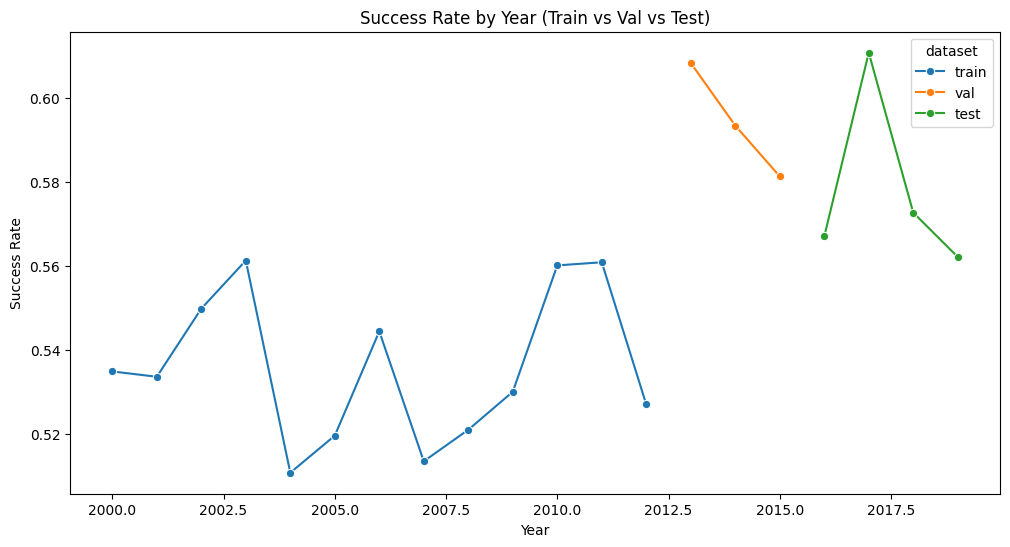

In [18]:
#Plot success rate across datasets

plt.figure(figsize=(12,6))
sns.lineplot(data=yearly_success, x='year', y='success', hue='dataset', marker='o')

plt.title('Success Rate by Year (Train vs Val vs Test)')
plt.ylabel('Success Rate')
plt.xlabel('Year')

plt.show()

In [19]:
#Function to compute yearly success by budget bucket

def compute_yearly_bucket_success(df, name):
    out = (
        df.groupby(['year', 'budget_bucket'])['success']
        .mean()
        .reset_index()
    )
    out['dataset'] = name
    return out

train_y = compute_yearly_bucket_success(train, 'train')
val_y   = compute_yearly_bucket_success(val, 'val')
test_y  = compute_yearly_bucket_success(test, 'test')

all_y = pd.concat([train_y, val_y, test_y])

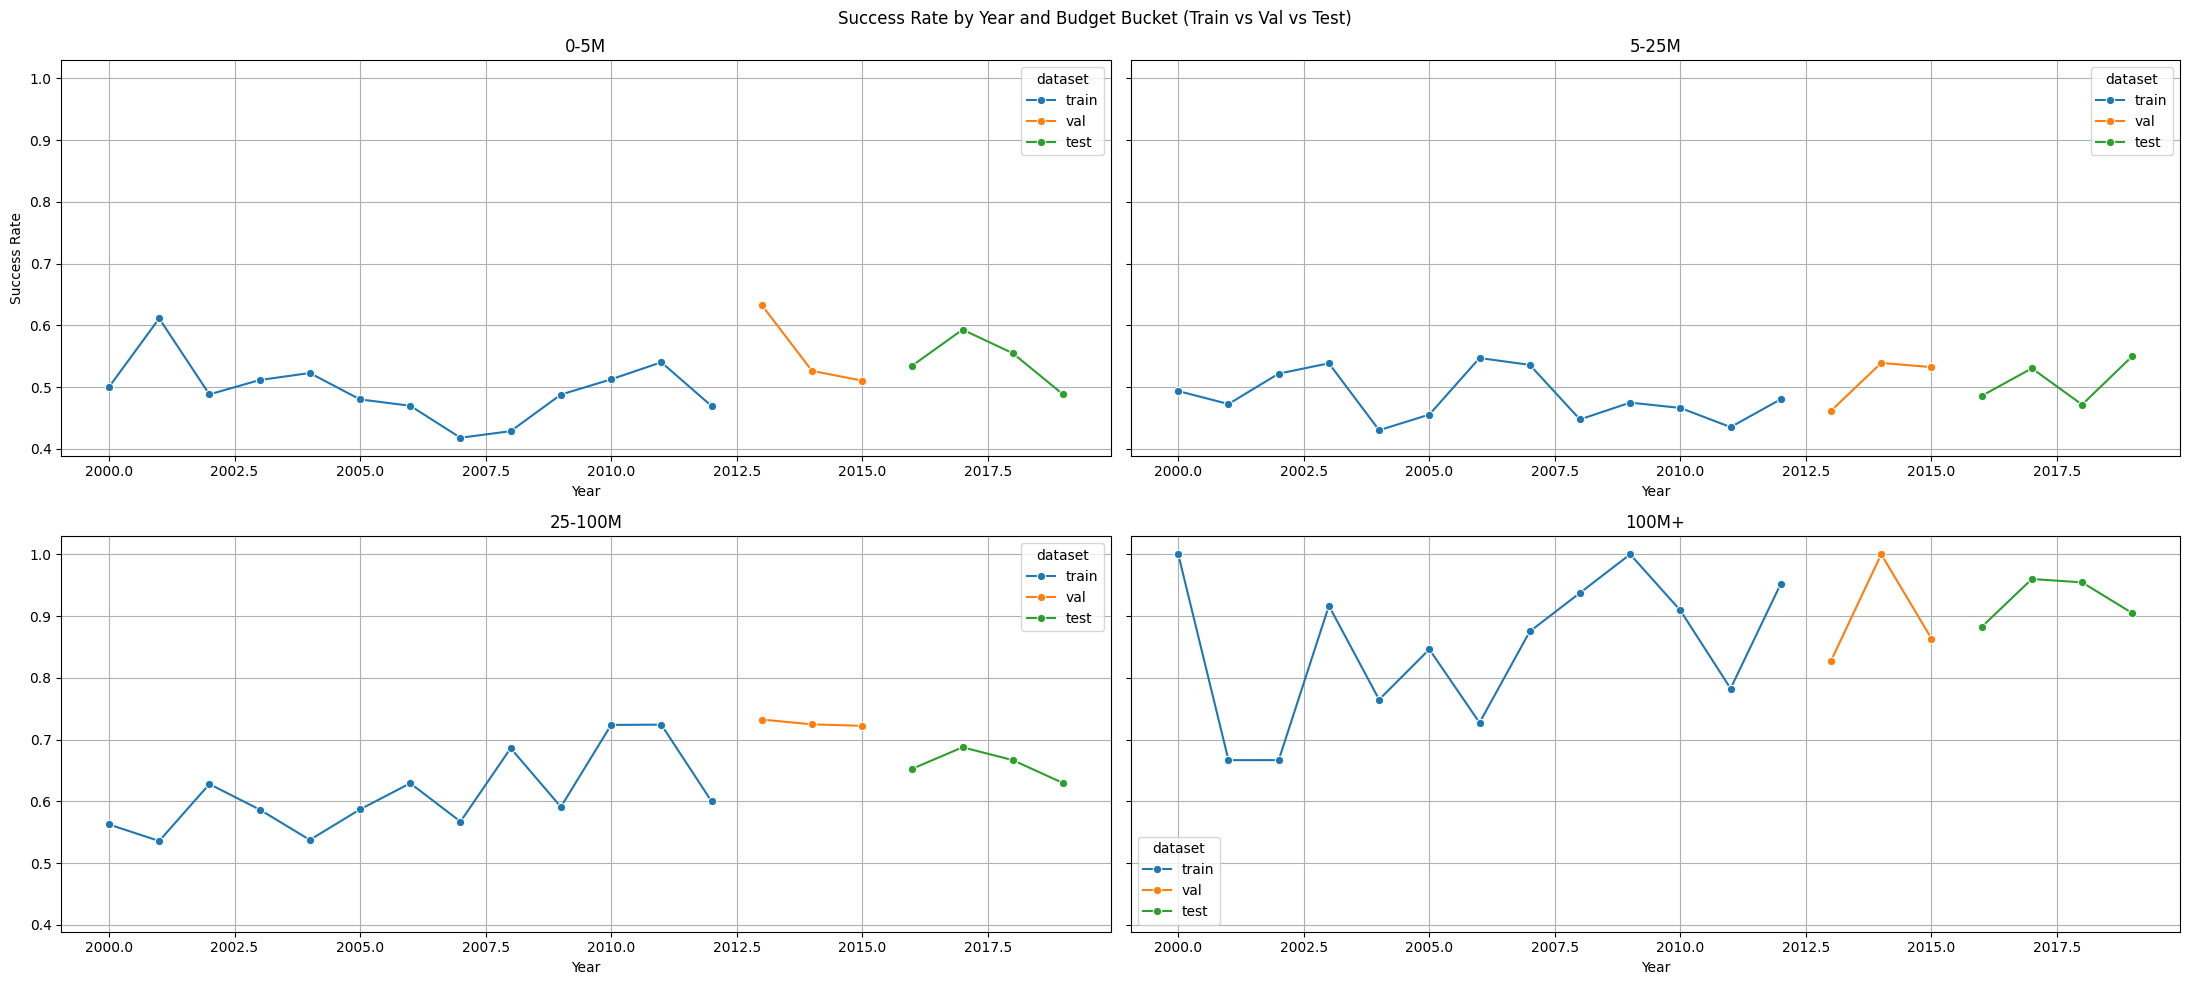

In [20]:
#Plot yearly success by budget bucket

buckets = ['0-5M', '5-25M', '25-100M', '100M+']

fig, axes = plt.subplots(2, 2, figsize=(22, 10), sharey=True)
axes = axes.flatten()

for i, bucket in enumerate(buckets):
    ax = axes[i]
    subset = all_y[all_y['budget_bucket'] == bucket]

    sns.lineplot(
        data=subset,
        x='year',
        y='success',
        hue='dataset',
        marker='o',
        ax=ax
    )

    ax.set_title(bucket)
    ax.set_xlabel('Year')
    if i == 0:
        ax.set_ylabel('Success Rate')
    else:
        ax.set_ylabel('')

    ax.grid(True)

plt.suptitle('Success Rate by Year and Budget Bucket (Train vs Val vs Test)')
plt.tight_layout()
plt.show()

In [21]:
#Function to calculate average success rate by bucket

def avg_success_by_bucket(df, name):
    out = (
        df.groupby('budget_bucket')['success']
        .mean()
        .reset_index()
    )
    out['dataset'] = name
    return out

In [22]:
#Calculate average success rate by bucket

train_avg = avg_success_by_bucket(train, 'train')
val_avg   = avg_success_by_bucket(val, 'val')
test_avg  = avg_success_by_bucket(test, 'test')

avg_table = pd.concat([train_avg, val_avg, test_avg])

avg_pivot = avg_table.pivot(index='budget_bucket', columns='dataset', values='success')

avg_pivot

dataset,test,train,val
budget_bucket,,,
0-5M,0.55,0.49,0.56
100M+,0.92,0.86,0.89
25-100M,0.66,0.61,0.73
5-25M,0.51,0.48,0.51


In [23]:
#Display differences in success rate in each dataset for each budget bucket

diffs = avg_pivot.copy()

diffs['val_vs_train_%']  = (diffs['val']  - diffs['train']) / diffs['train']
diffs['test_vs_train_%'] = (diffs['test'] - diffs['train']) / diffs['train']
diffs['test_vs_val_%']   = (diffs['test'] - diffs['val']) / diffs['val']

diffs = diffs.round(3)

diffs

dataset,test,train,val,val_vs_train_%,test_vs_train_%,test_vs_val_%
budget_bucket,,,,,,
0-5M,0.55,0.49,0.56,0.14,0.12,-0.02
100M+,0.92,0.86,0.89,0.04,0.07,0.03
25-100M,0.66,0.61,0.73,0.18,0.08,-0.09
5-25M,0.51,0.48,0.51,0.06,0.05,-0.00


In [24]:
#Instantiate models to test on validation set

models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8, random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=10, random_state=42, n_jobs=-1
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=1000, random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300, max_depth=3, random_state=42
    )
}

# **Evaluate all Models on Validation Set**

In [25]:
#Train and evaluate each of the models on the validation set

pd.options.display.float_format = '{:.3f}'.format

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_val)

    report = classification_report(y_val, preds, output_dict=True)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, preds),
        "Precision": report['1']['precision'],
        "Recall": report['1']['recall'],
        "F1": report['1']['f1-score']
    })

results_df = pd.DataFrame(results) \
    .sort_values(by="F1", ascending=False) \
    .round(3)

results_df

,Model,Accuracy,Precision,Recall,F1
3,Gradient Boosting,0.624,0.677,0.705,0.691
1,Random Forest,0.613,0.684,0.649,0.666
0,Decision Tree,0.606,0.684,0.626,0.654
2,Logistic Regression,0.619,0.717,0.594,0.649


In [26]:
#Function to plot confusion matricies for each model and each budget bucket - Some of this code block was generated using outside sources

def plot_confusion_by_bucket(model, model_name, X_val, y_val, val_df):

    # Predictions
    preds = model.predict(X_val)

    # Build dataframe
    df = val_df.copy()
    df['actual_success'] = y_val
    df['pred_success'] = preds

    # Budget buckets
    def bucket_budget(b):
        if b <= 5_000_000:
            return '0-5M'
        elif b <= 25_000_000:
            return '5-25M'
        elif b <= 100_000_000:
            return '25-100M'
        else:
            return '100M+'

    df['budget_bucket'] = df['budget'].apply(bucket_budget)

    buckets = ['0-5M', '5-25M', '25-100M', '100M+']

    fig, axes = plt.subplots(1, len(buckets), figsize=(20, 5))

    for ax, bucket in zip(axes, buckets):
        subset = df[df['budget_bucket'] == bucket]

        y_true = subset['actual_success']
        y_pred = subset['pred_success']

        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        cm_percent = cm / cm.sum() * 100 if cm.sum() > 0 else np.zeros_like(cm)

        labels = np.array([
            [f"TN\n{cm[0,0]}\n({cm_percent[0,0]:.1f}%)", f"FP\n{cm[0,1]}\n({cm_percent[0,1]:.1f}%)"],
            [f"FN\n{cm[1,0]}\n({cm_percent[1,0]:.1f}%)", f"TP\n{cm[1,1]}\n({cm_percent[1,1]:.1f}%)"]
        ])

        sns.heatmap(
            cm,
            annot=labels,
            fmt='',
            cmap='Blues',
            cbar=False,
            xticklabels=['Failure', 'Success'],
            yticklabels=['Failure', 'Success'],
            ax=ax
        )

        acc = accuracy_score(y_true, y_pred)
        ax.set_title(f'{bucket}\nN={len(subset)} | Acc={acc:.2f}')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')

    plt.suptitle(f'{model_name} - Confusion Matrices by Budget Bucket', fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

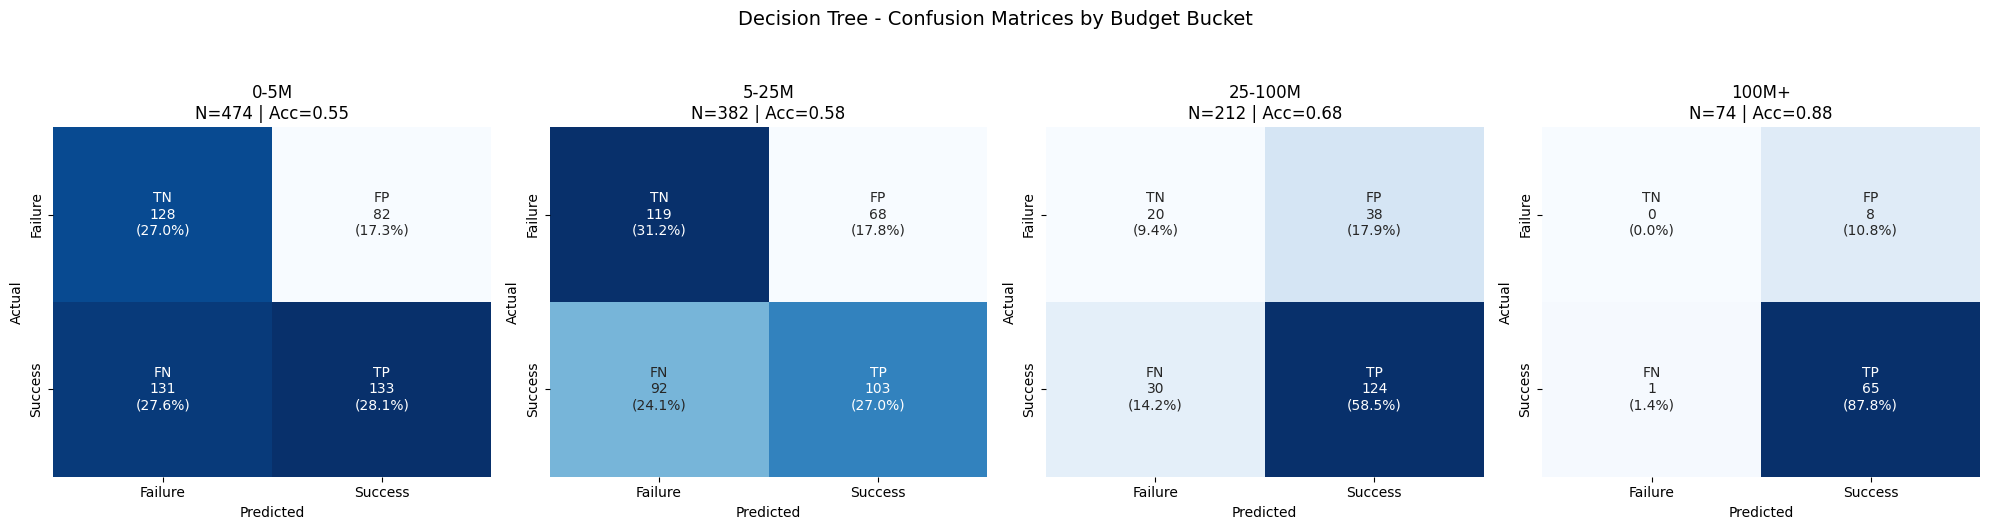

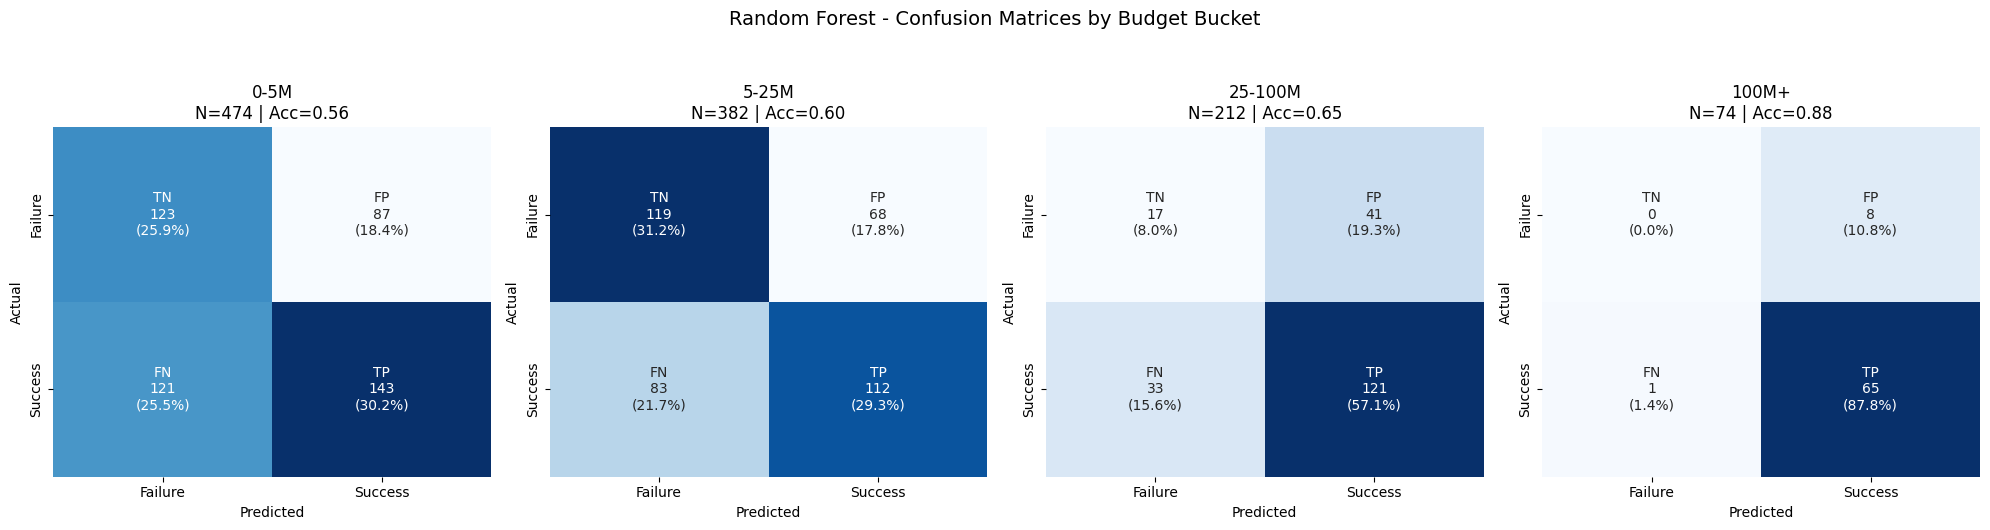

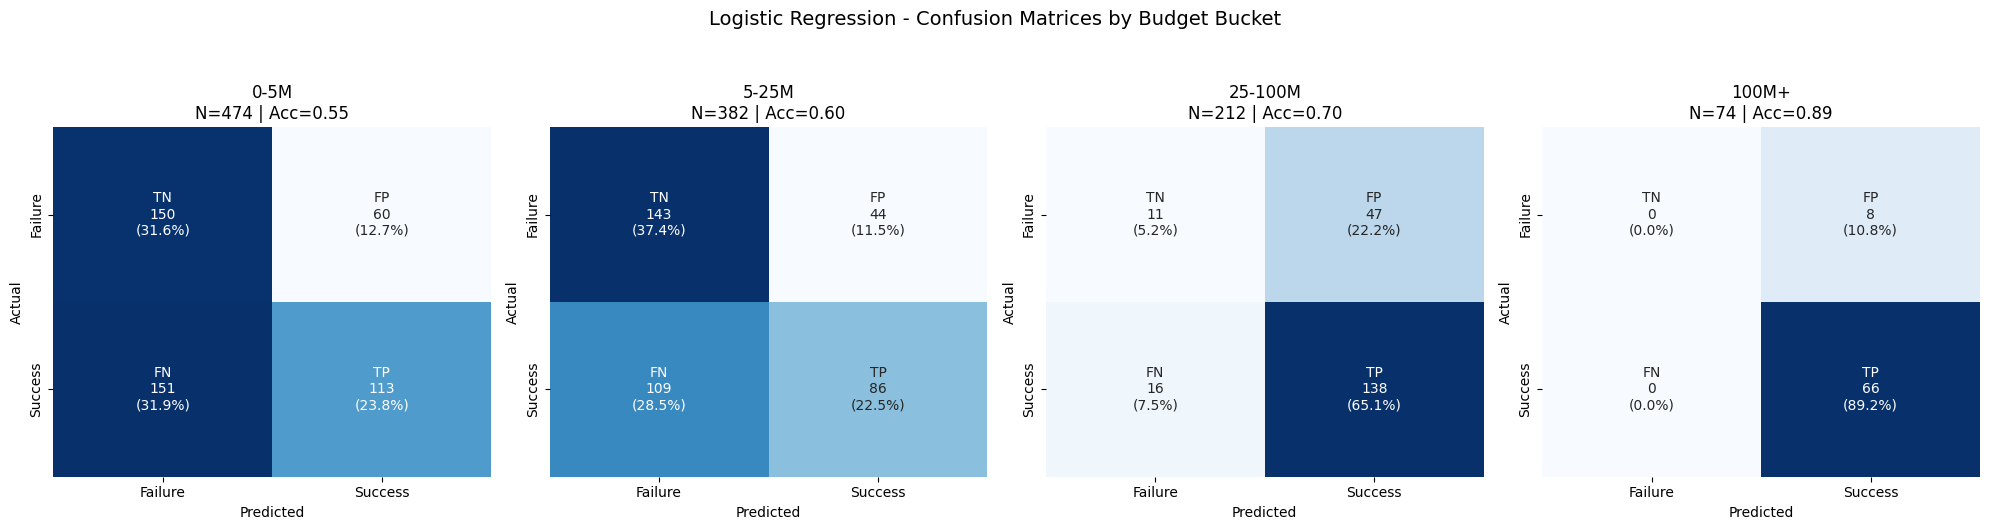

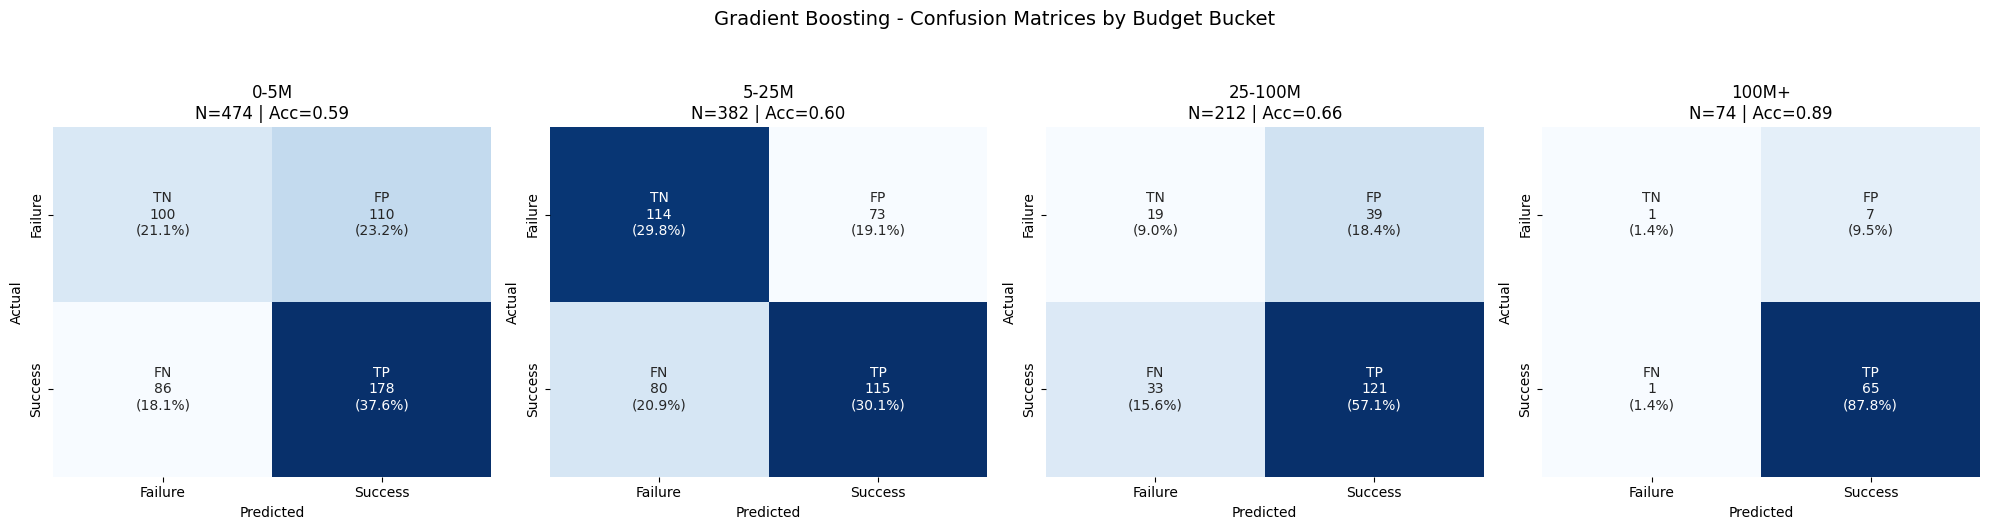

In [27]:
#Display confusion matricies

for name, model in models.items():
    plot_confusion_by_bucket(model, name, X_val, y_val, val)

In [28]:
#Calculate how much better than random/all positive predictions each model was

baseline_precision = y_val.mean()

for name, model in models.items():
    preds = model.predict(X_val)
    probs = model.predict_proba(X_val)[:, 1]

    precision = precision_score(y_val, preds)

    fpr, tpr, _ = roc_curve(y_val, probs)
    roc_auc = auc(fpr, tpr)

    print(f"{name}:")
    print(f"  AUC: {roc_auc:.3f}")
    print(f"  Better than random: {(roc_auc - 0.5)*100:.1f}%")
    print(f"  Better than all positive: {(precision - baseline_precision)*100:.1f}%")

Decision Tree:
  AUC: 0.620
  Better than random: 12.0%
  Better than all positive: 9.0%
Random Forest:
  AUC: 0.664
  Better than random: 16.4%
  Better than all positive: 8.9%
Logistic Regression:
  AUC: 0.664
  Better than random: 16.4%
  Better than all positive: 12.3%
Gradient Boosting:
  AUC: 0.664
  Better than random: 16.4%
  Better than all positive: 8.2%


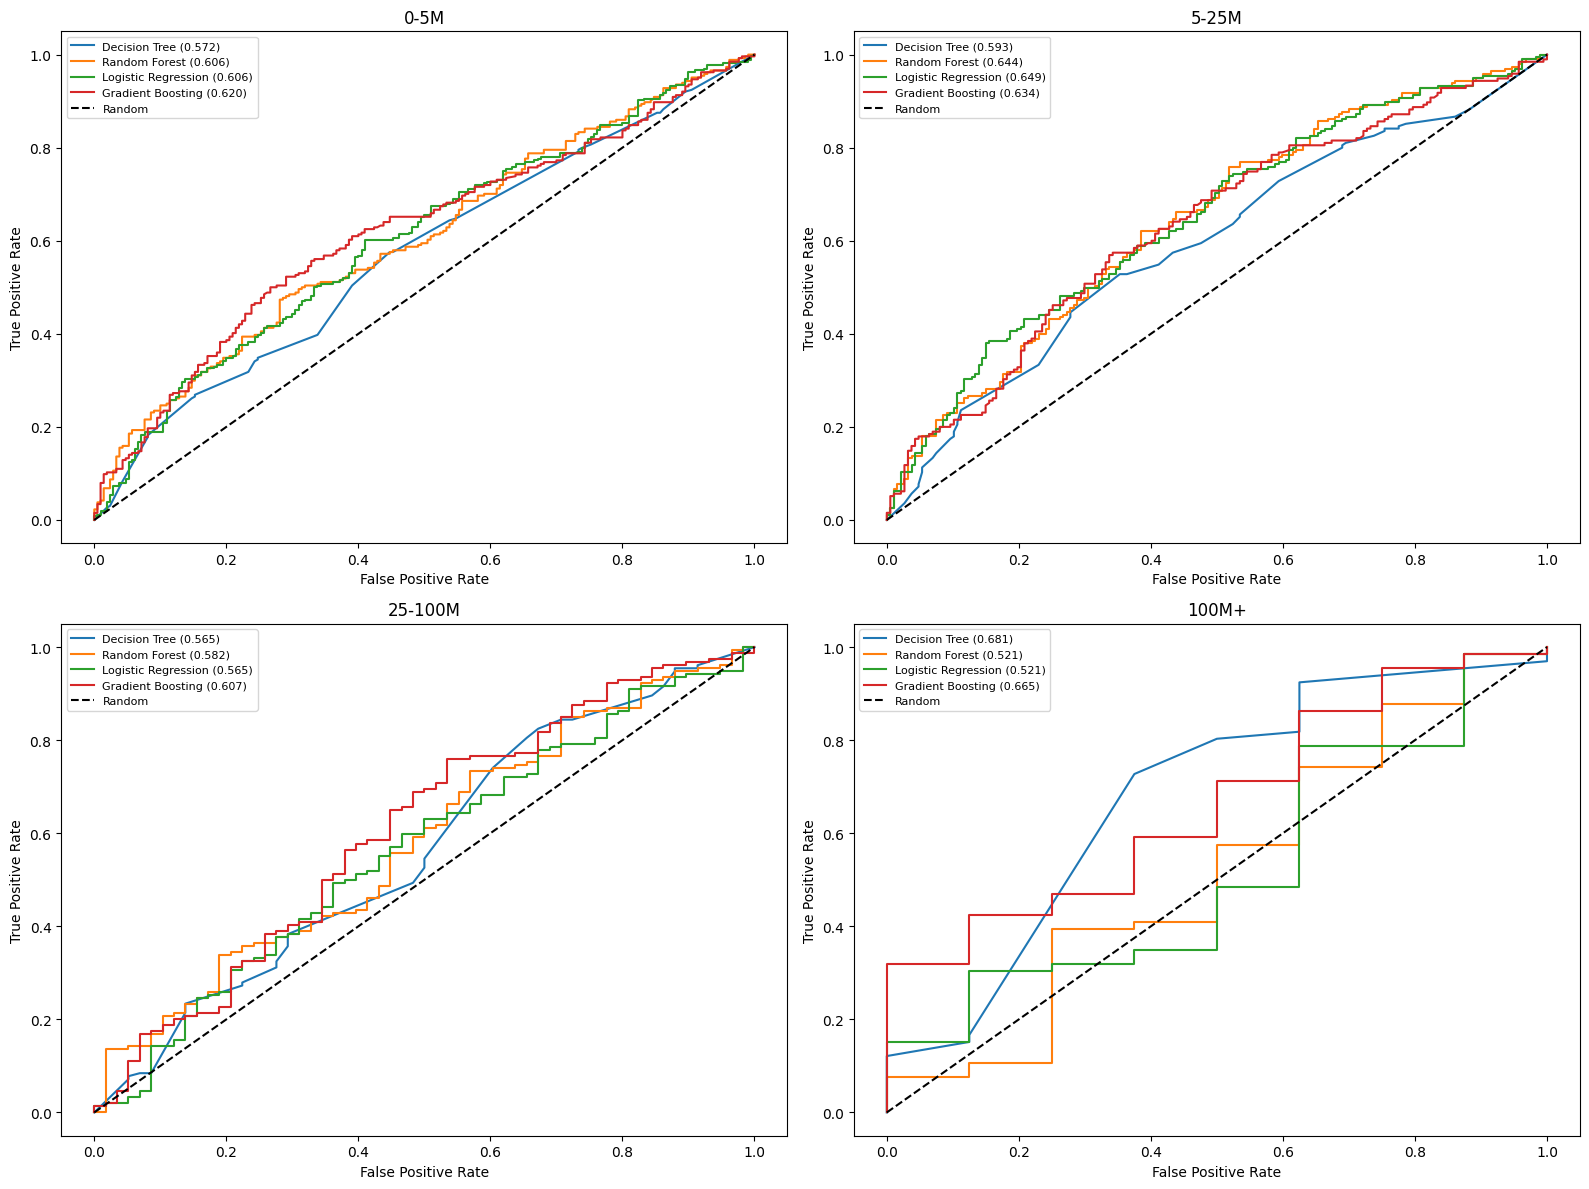

In [29]:
#Display ROC curves for each model and each budget bucket

buckets = ['0-5M', '5-25M', '25-100M', '100M+']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, bucket in enumerate(buckets):
    ax = axes[i]

    mask = val['budget_bucket'] == bucket

    X_bucket = X_val.loc[mask]
    y_bucket = y_val.loc[mask]

    for name, model in models.items():
        probs = model.predict_proba(X_bucket)[:, 1]
        fpr, tpr, _ = roc_curve(y_bucket, probs)
        roc_auc = auc(fpr, tpr)

        ax.plot(fpr, tpr, label=f"{name} ({roc_auc:.3f})")

    ax.plot([0,1], [0,1], 'k--', label='Random')

    ax.set_title(bucket)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [30]:
#Show each models performance in each budget bucket

all_results = []

for bucket in buckets:
    mask = val['budget_bucket'] == bucket

    X_bucket = X_val.loc[mask]
    y_bucket = y_val.loc[mask]

    baseline_precision = y_bucket.mean()

    for name, model in models.items():
        preds = model.predict(X_bucket)
        probs = model.predict_proba(X_bucket)[:, 1]

        precision = precision_score(y_bucket, preds)
        recall = recall_score(y_bucket, preds)

        fpr, tpr, _ = roc_curve(y_bucket, probs)
        roc_auc = auc(fpr, tpr)

        all_results.append({
            "Bucket": bucket,
            "Model": name,
            "Precision": precision,
            "Recall": recall,
            "AUC": roc_auc,
            "Better_than_random_%": (roc_auc - 0.5)*100,
            "Better_than_all_positive_%": (precision - baseline_precision) * 100
        })

df_results = pd.DataFrame(all_results)

display(df_results)

,Bucket,Model,Precision,Recall,AUC,Better_than_random_%,Better_than_all_positive_%
0,0-5M,Decision Tree,0.619,0.504,0.572,7.222,6.164
1,0-5M,Random Forest,0.622,0.542,0.606,10.565,6.478
2,0-5M,Logistic Regression,0.653,0.428,0.606,10.583,9.622
3,0-5M,Gradient Boosting,0.618,0.674,0.620,12.012,6.109
4,5-25M,Decision Tree,0.602,0.528,0.593,9.271,9.187
5,5-25M,Random Forest,0.622,0.574,0.644,14.421,11.175
6,5-25M,Logistic Regression,0.662,0.441,0.649,14.865,15.107
7,5-25M,Gradient Boosting,0.612,0.590,0.634,13.361,10.123
8,25-100M,Decision Tree,0.765,0.805,0.565,6.533,3.902
9,25-100M,Random Forest,0.747,0.786,0.582,8.150,2.050


# **Hyperparameter Tuning for Gradient Boosting Classifier Model on Val Set**

In [31]:
#Complete hyperparameter tuning for our model of choice on the validation set

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 3, 5],
    'subsample': [1.0, 0.8]
}

results = []

for params in ParameterGrid(param_grid):
    gbc = GradientBoostingClassifier(
        random_state=42,
        **params
    )

    gbc.fit(X_train, y_train)

    preds = gbc.predict(X_val)
    probs = gbc.predict_proba(X_val)[:, 1]

    results.append({
        'n_estimators': params['n_estimators'],
        'learning_rate': params['learning_rate'],
        'max_depth': params['max_depth'],
        'min_samples_split': params['min_samples_split'],
        'min_samples_leaf': params['min_samples_leaf'],
        'subsample': params['subsample'],
        'accuracy': accuracy_score(y_val, preds),
        'precision': precision_score(y_val, preds),
        'recall': recall_score(y_val, preds),
        'f1': f1_score(y_val, preds),
        'auc': roc_auc_score(y_val, probs)
    })

tuning_results = pd.DataFrame(results).sort_values('f1', ascending=False)
tuning_results.head(10)

,n_estimators,learning_rate,max_depth,min_samples_split,min_samples_leaf,subsample,accuracy,precision,recall,f1,auc
483,200,0.100,4,20,5,0.800,0.632,0.682,0.716,0.698,0.667
454,300,0.100,4,2,3,1.000,0.635,0.687,0.710,0.698,0.662
388,300,0.100,3,10,1,1.000,0.633,0.684,0.711,0.697,0.668
406,300,0.100,3,10,3,1.000,0.630,0.681,0.711,0.696,0.664
404,200,0.100,3,10,3,1.000,0.630,0.682,0.710,0.696,0.664
299,300,0.050,4,10,3,0.800,0.631,0.685,0.704,0.694,0.663
466,300,0.100,4,20,3,1.000,0.630,0.684,0.704,0.694,0.662
386,200,0.100,3,10,1,1.000,0.629,0.682,0.704,0.693,0.664
398,200,0.100,3,2,3,1.000,0.630,0.684,0.701,0.692,0.666
440,200,0.100,4,10,1,1.000,0.629,0.683,0.701,0.692,0.662


# **Evaluate Gradient Boosting Classifier Model on Test Set**

In [32]:
#Instantiate our final model using tuned hyperparameters and test on the held-out test set

gbc = GradientBoostingClassifier(
        n_estimators=200,
        max_depth=4,
        min_samples_split=20,
        min_samples_leaf=5,
        subsample=0.8,
        learning_rate=0.1,
        random_state=42
    )

gbc.fit(X_train, y_train)

preds = gbc.predict(X_test)

report = classification_report(y_test, preds, output_dict=True)

results_df = pd.DataFrame([{
    "Model": "Gradient Boosting",
    "Accuracy": accuracy_score(y_test, preds),
    "Precision_1": report['1']['precision'],
    "Recall_1": report['1']['recall'],
    "F1_1": report['1']['f1-score']
}])

results_df

,Model,Accuracy,Precision_1,Recall_1,F1_1
0,Gradient Boosting,0.613,0.658,0.692,0.674


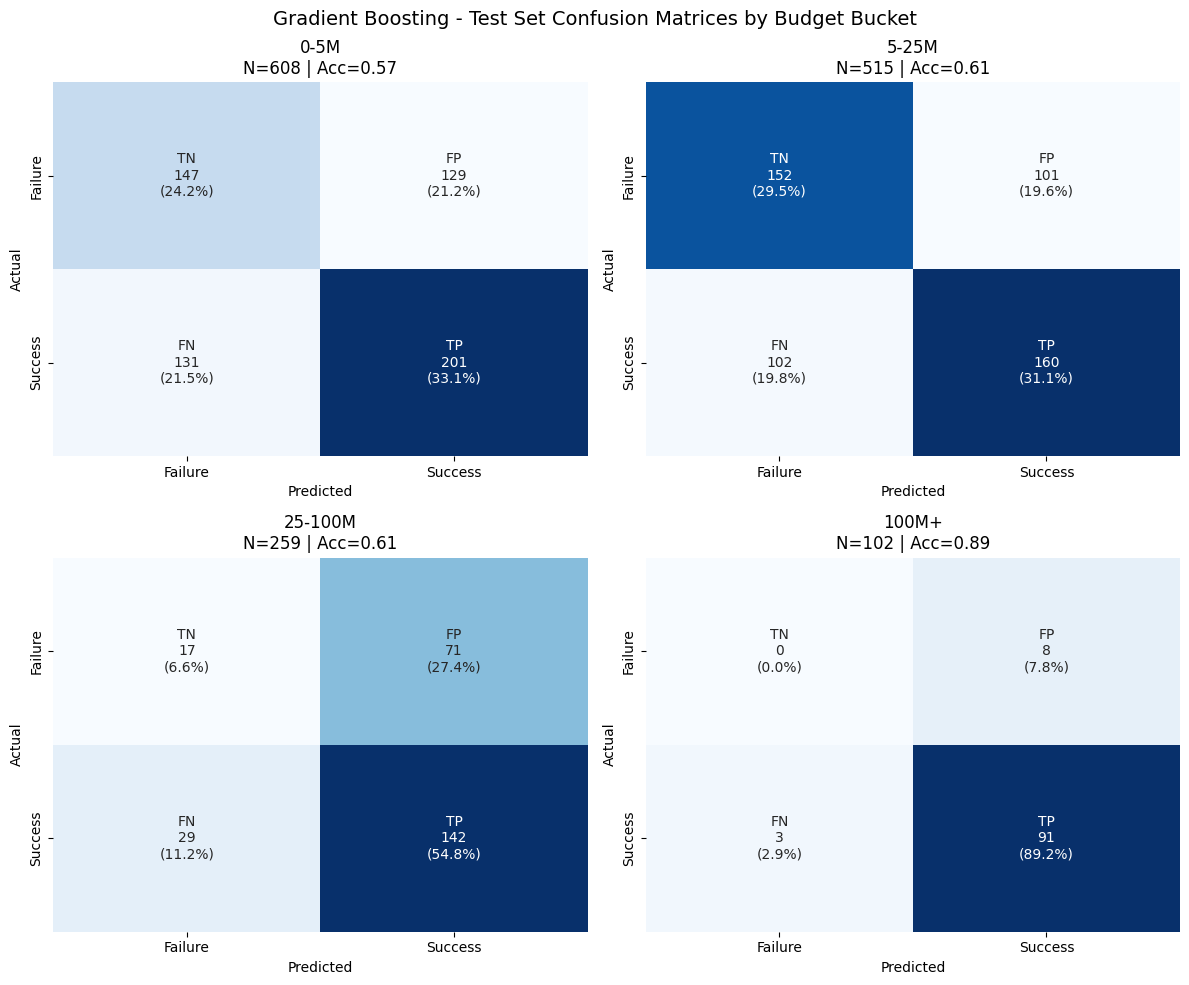

In [33]:
#Display confusion matricies for this model across all budget buckets - Some of this code block was generated using outside sources

preds = gbc.predict(X_test)

df = test.copy()
df['actual_success'] = y_test.values
df['pred_success'] = preds

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, bucket in zip(axes, buckets):
    subset = df[df['budget_bucket'] == bucket]

    y_true = subset['actual_success']
    y_pred = subset['pred_success']

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    cm_percent = cm / cm.sum() * 100 if cm.sum() > 0 else np.zeros_like(cm)

    labels = np.array([
        [f"TN\n{cm[0,0]}\n({cm_percent[0,0]:.1f}%)", f"FP\n{cm[0,1]}\n({cm_percent[0,1]:.1f}%)"],
        [f"FN\n{cm[1,0]}\n({cm_percent[1,0]:.1f}%)", f"TP\n{cm[1,1]}\n({cm_percent[1,1]:.1f}%)"]
    ])

    sns.heatmap(
        cm,
        annot=labels,
        fmt='',
        cmap='Blues',
        cbar=False,
        xticklabels=['Failure', 'Success'],
        yticklabels=['Failure', 'Success'],
        ax=ax
    )

    acc = accuracy_score(y_true, y_pred)
    ax.set_title(f'{bucket}\nN={len(subset)} | Acc={acc:.2f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Gradient Boosting - Test Set Confusion Matrices by Budget Bucket', fontsize=14)
plt.tight_layout()
plt.show()

In [34]:
#Calculate how much better than a random/all-positive classifier our model performed on the test set

baseline_precision = y_test.mean()

preds = gbc.predict(X_test)
probs = gbc.predict_proba(X_test)[:, 1]

precision = precision_score(y_test, preds)

fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

print("Gradient Boosting:")
print(f"  AUC: {roc_auc:.3f}")
print(f"  Better than random: {(roc_auc - 0.5)*100:.1f}%")
print(f"  Better than all positive: {(precision - baseline_precision)*100:.1f}%")

Gradient Boosting:
  AUC: 0.641
  Better than random: 14.1%
  Better than all positive: 7.9%


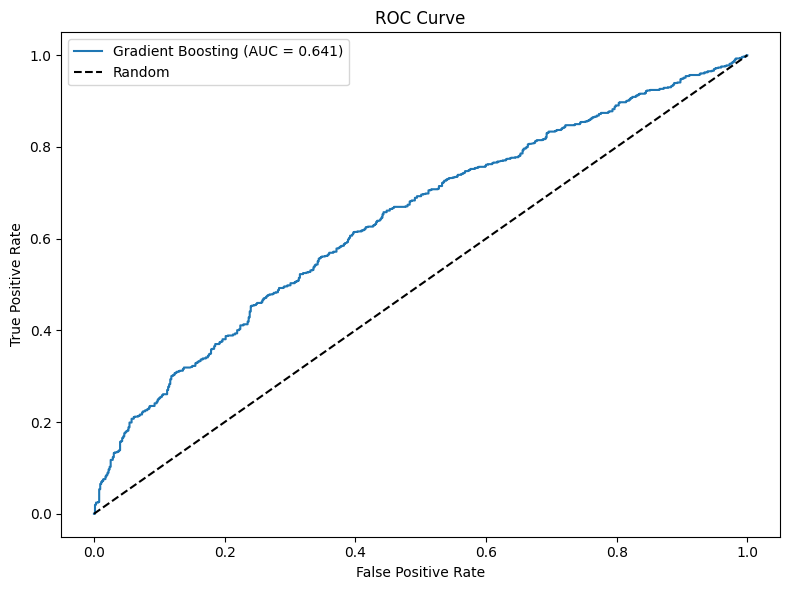

In [35]:
#Plot ROC Curve for our model overall on the test set

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f"Gradient Boosting (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.tight_layout()
plt.show()

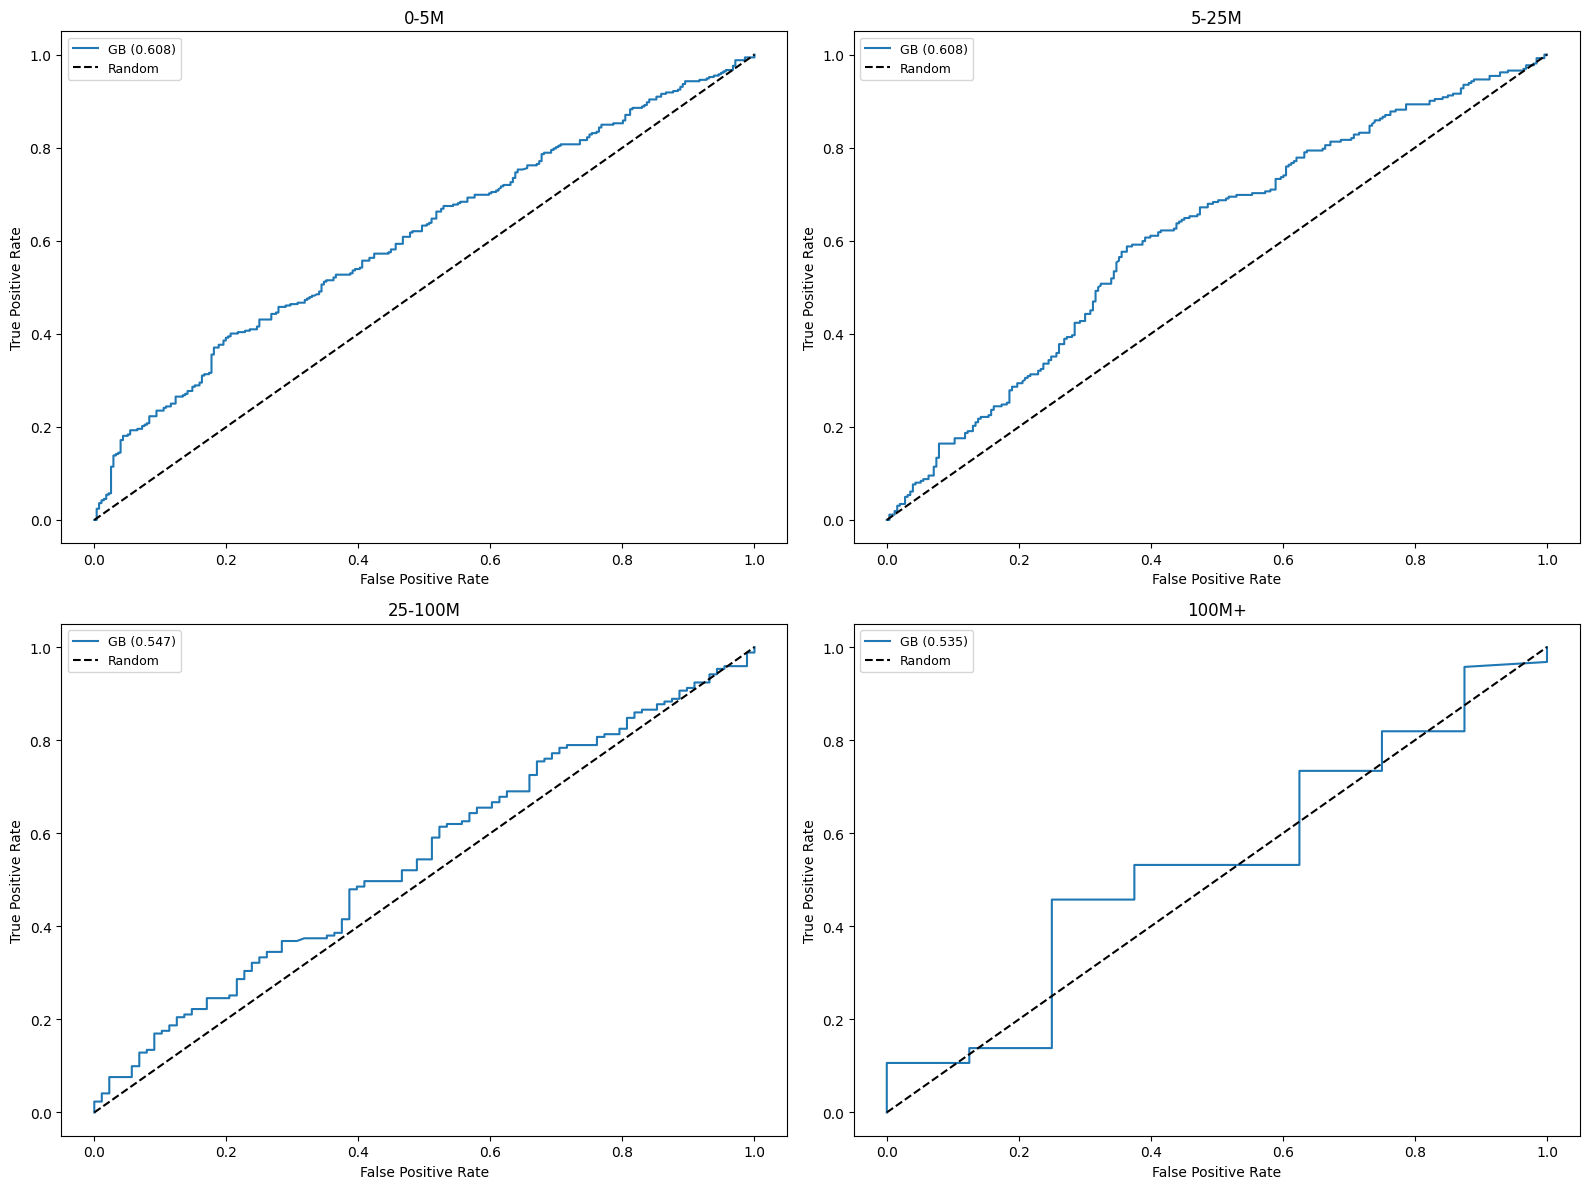

In [36]:
#Plot ROC Curve for our model on each budget bucket on the test set

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, bucket in enumerate(buckets):
    ax = axes[i]

    mask = test['budget_bucket'] == bucket

    X_bucket = X_test.loc[mask]
    y_bucket = y_test.loc[mask]

    probs = gbc.predict_proba(X_bucket)[:, 1]
    fpr, tpr, _ = roc_curve(y_bucket, probs)
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, label=f"GB ({roc_auc:.3f})")

    ax.plot([0,1], [0,1], 'k--', label='Random')

    ax.set_title(bucket)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [37]:
#Show our model's performance in each budget bucket on the test set

all_results = []

for bucket in buckets:
    mask = test['budget_bucket'] == bucket

    X_bucket = X_test.loc[mask]
    y_bucket = y_test.loc[mask]

    baseline_precision = y_bucket.mean()

    preds = gbc.predict(X_bucket)
    probs = gbc.predict_proba(X_bucket)[:, 1]

    precision = precision_score(y_bucket, preds)
    recall = recall_score(y_bucket, preds)

    fpr, tpr, _ = roc_curve(y_bucket, probs)
    roc_auc = auc(fpr, tpr)

    all_results.append({
        "Bucket": bucket,
        "Model": "Gradient Boosting",
        "Precision": precision,
        "Recall": recall,
        "AUC": roc_auc,
        "Better_than_random_%": (roc_auc - 0.5)*100,
        "Better_than_all_positive_%": (precision - baseline_precision) * 100
    })

df_results = pd.DataFrame(all_results)

display(df_results)

,Bucket,Model,Precision,Recall,AUC,Better_than_random_%,Better_than_all_positive_%
0,0-5M,Gradient Boosting,0.609,0.605,0.608,10.815,6.304
1,5-25M,Gradient Boosting,0.613,0.611,0.608,10.820,10.429
2,25-100M,Gradient Boosting,0.667,0.830,0.547,4.688,0.644
3,100M+,Gradient Boosting,0.919,0.968,0.535,3.524,-0.238


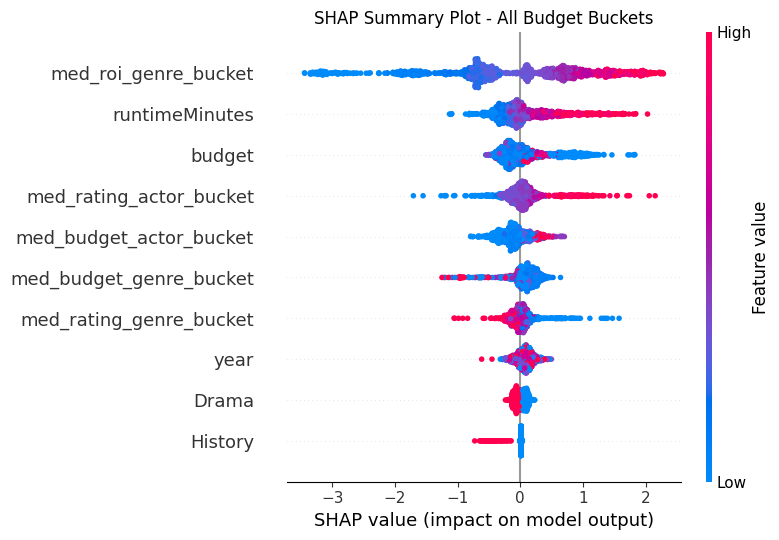

In [38]:
#Create a SHAP plot for our model overall on the test set

shap_values = shap.TreeExplainer(gbc).shap_values(X_test)

if isinstance(shap_values, list):
    shap_to_plot = shap_values[1]
else:
    shap_to_plot = shap_values

shap.summary_plot(shap_to_plot, X_test, max_display=10, show=False)
plt.title("SHAP Summary Plot - All Budget Buckets")
plt.tight_layout()
plt.show()

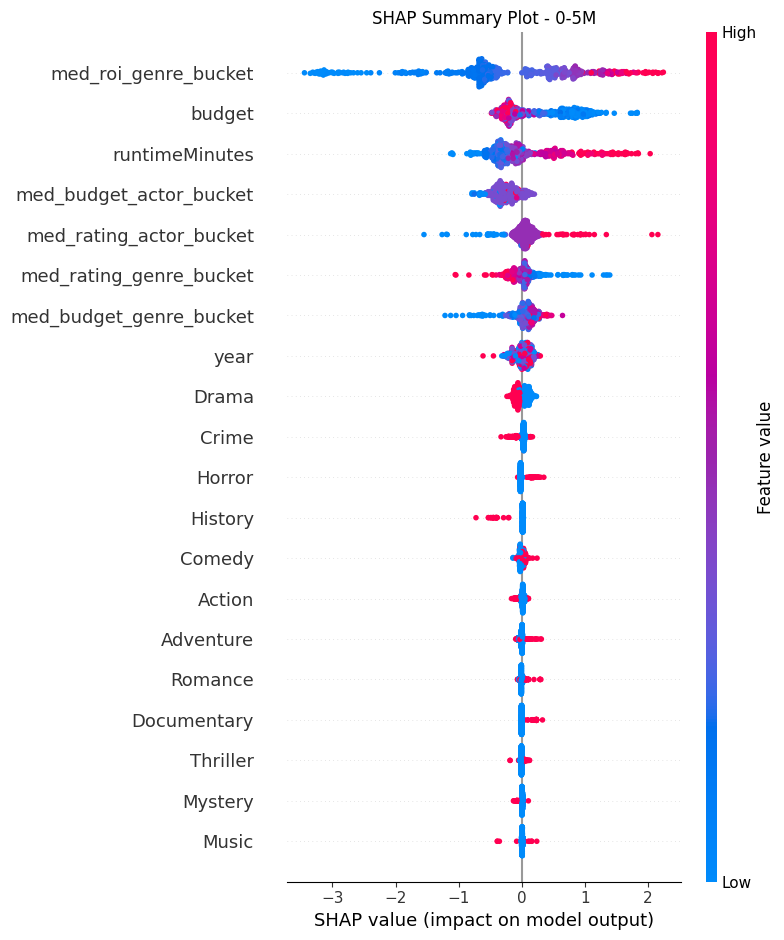

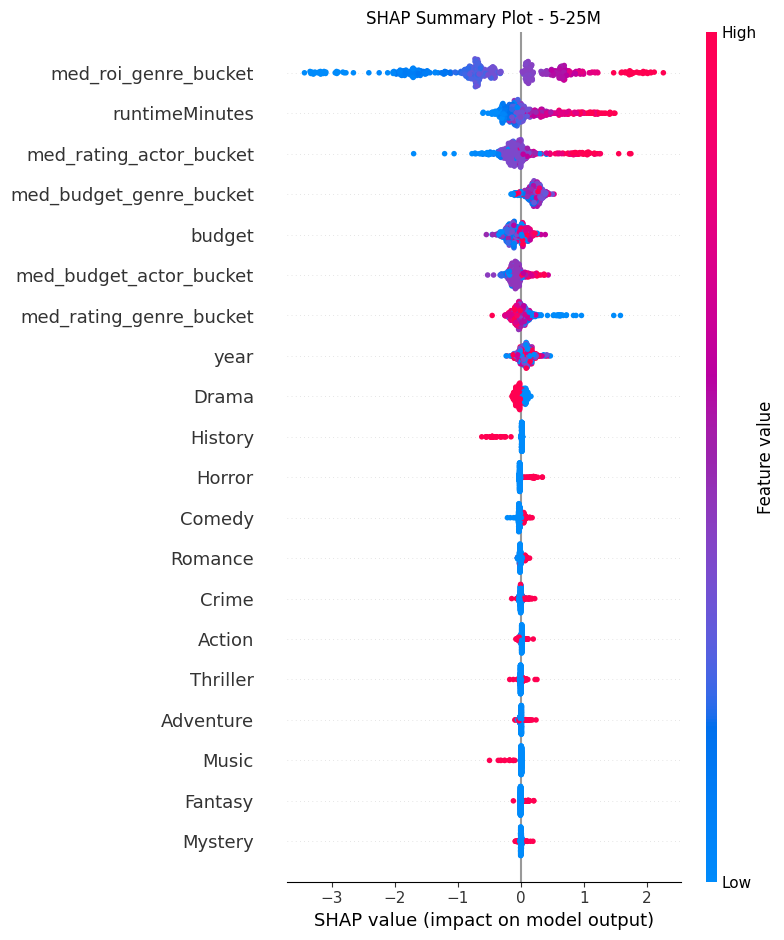

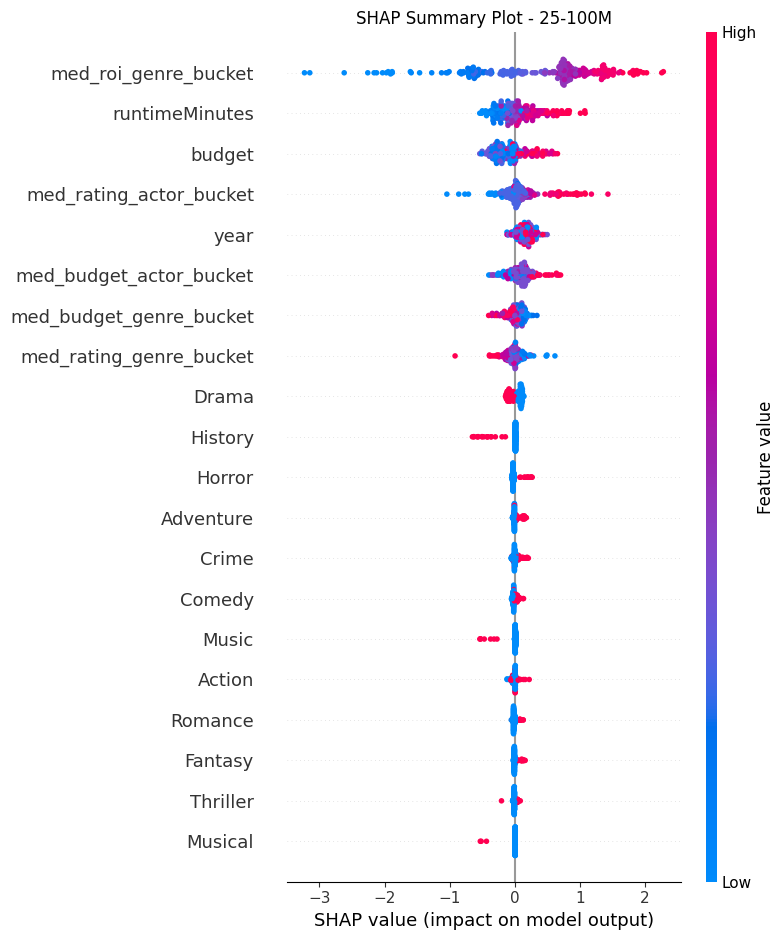

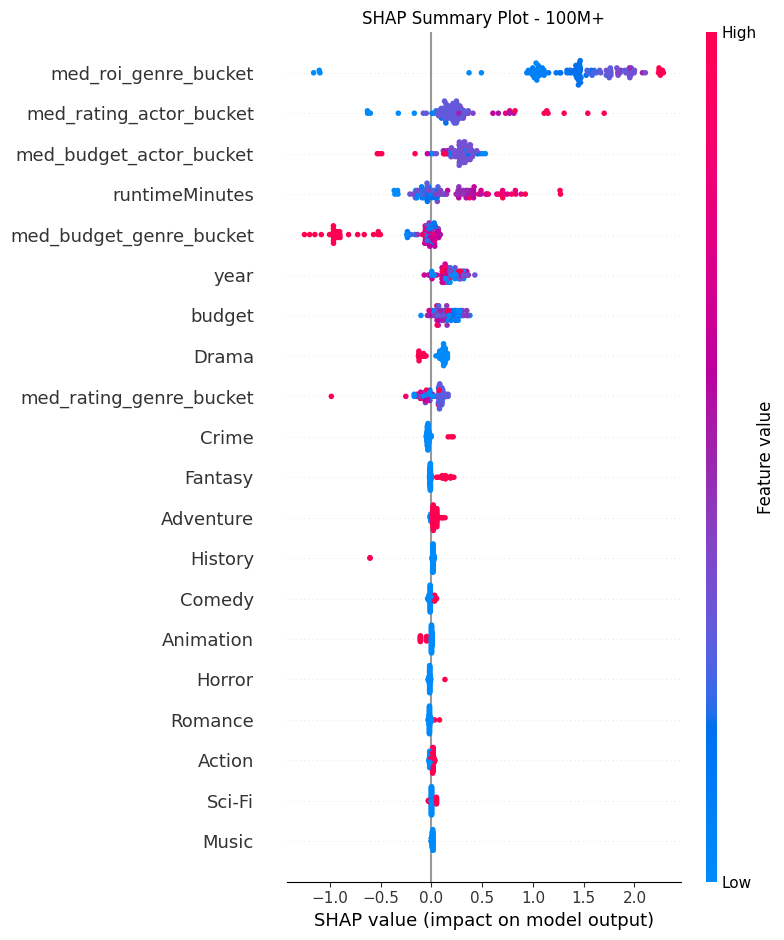

In [39]:
#Create SHAP plots for our model for each budget bucket on the test set

for bucket in buckets:
    mask = test['budget_bucket'] == bucket
    X_bucket = X_test.loc[mask]

    shap_values = shap.TreeExplainer(gbc).shap_values(X_bucket)

    if isinstance(shap_values, list):
        shap_to_plot = shap_values[1]
    else:
        shap_to_plot = shap_values

    shap.summary_plot(shap_to_plot, X_bucket, show=False)
    plt.title(f"SHAP Summary Plot - {bucket}")
    plt.tight_layout()
    plt.show()

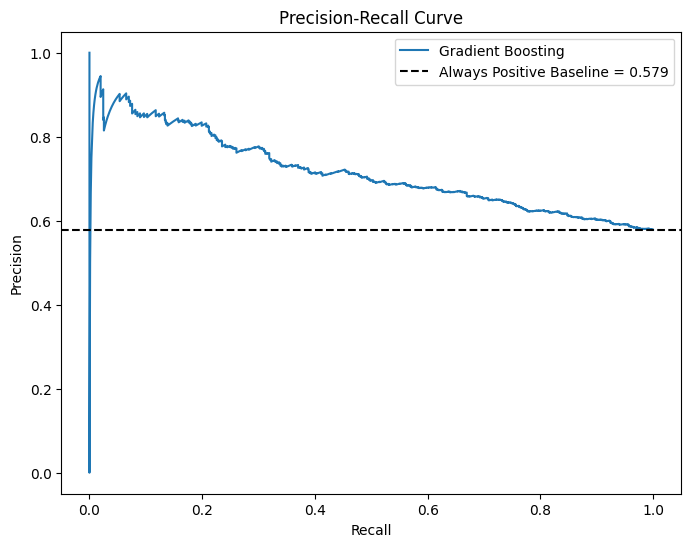

In [40]:
#Create precision-recall curve for our model overall on the test set

probs = gbc.predict_proba(X_test)[:, 1]

precision, recall, _ = precision_recall_curve(y_test, probs)

baseline = y_test.mean()

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label='Gradient Boosting')
plt.axhline(baseline, linestyle='--', color='black', label=f'Always Positive Baseline = {baseline:.3f}')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

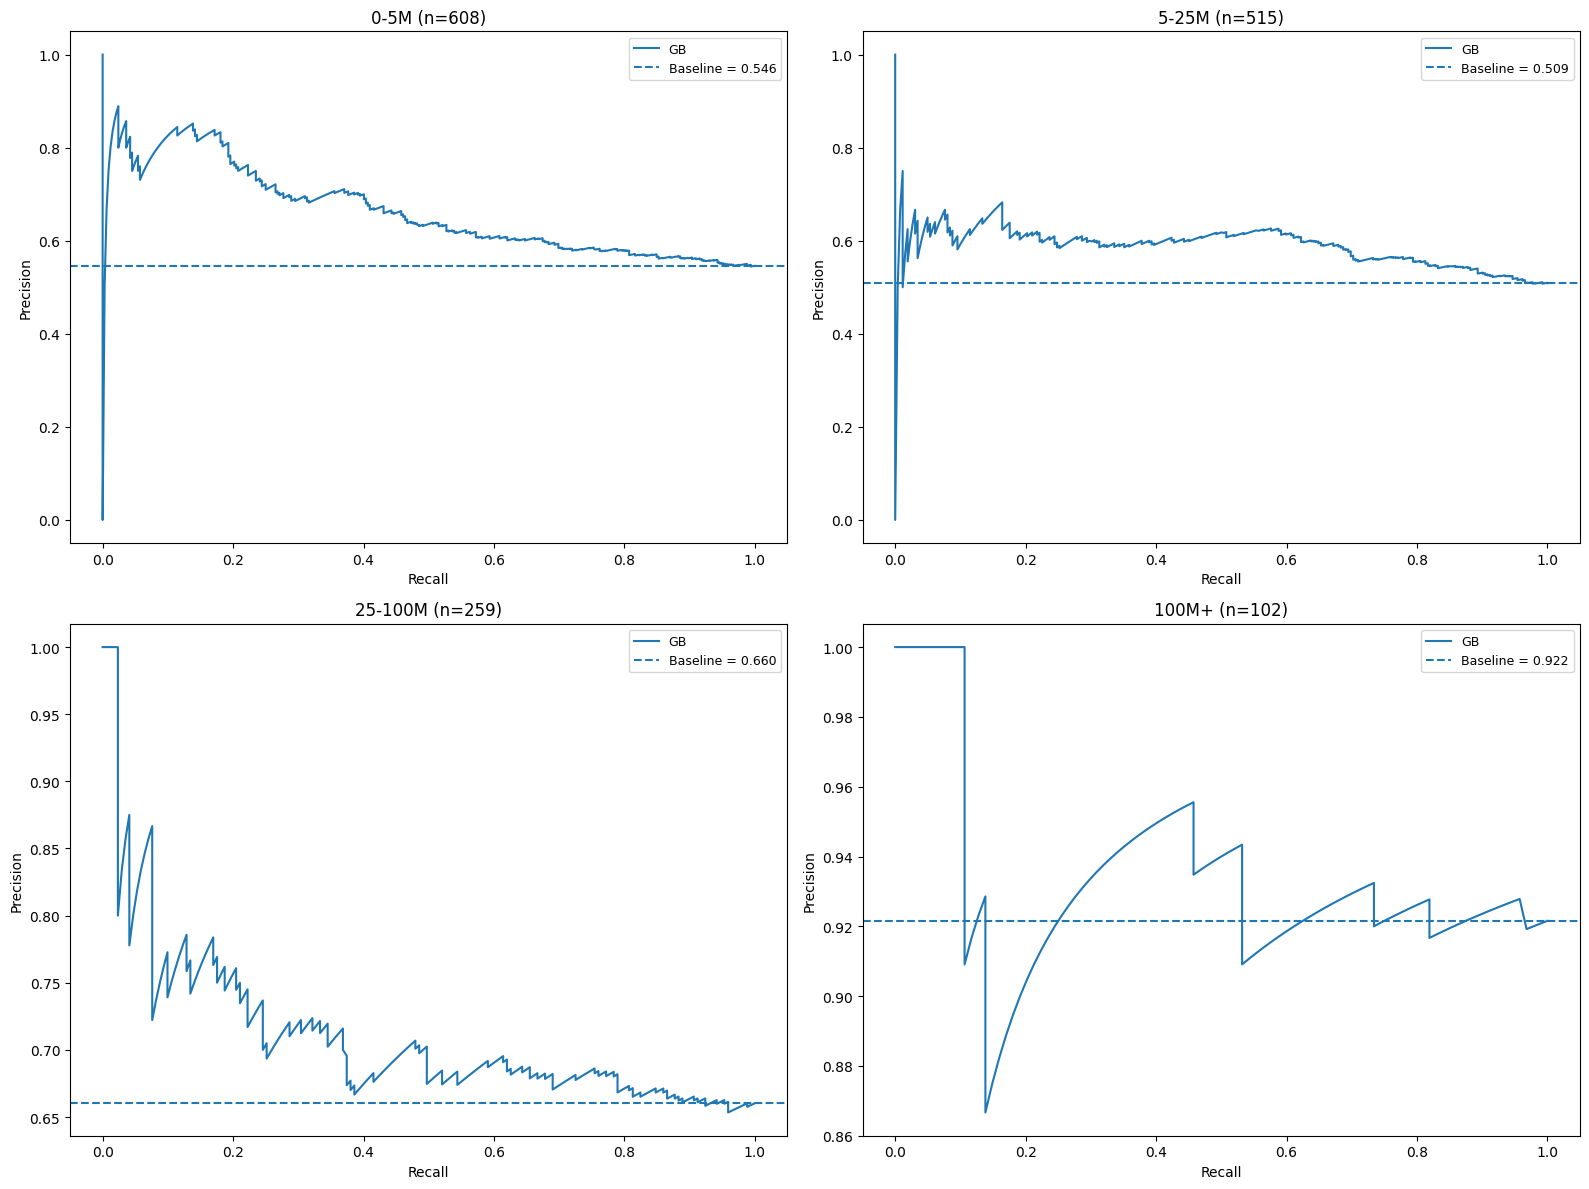

In [41]:
#Create precision-recall curves for our model for each budget bucket on the test set

test = test.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, bucket in enumerate(buckets):
    ax = axes[i]

    mask = test['budget_bucket'] == bucket

    X_bucket = X_test.loc[mask]
    y_bucket = y_test.loc[mask]

    probs = gbc.predict_proba(X_bucket)[:, 1]

    precision, recall, _ = precision_recall_curve(y_bucket, probs)

    baseline = y_bucket.mean()

    ax.plot(recall, precision, label='GB')
    ax.axhline(baseline, linestyle='--', label=f'Baseline = {baseline:.3f}')

    ax.set_title(f"{bucket} (n={len(y_bucket)})")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()